# GraphTelNet — Telomeric Tumor Status Prediction



In [1]:
!pip -q install torch_geometric
!pip -q install numpy pandas scipy scikit-learn tqdm requests matplotlib
!pip -q install "git+https://github.com/ucscXena/xenaPython"

  Preparing metadata (setup.py) ... done


In [2]:
import os, io, random
import numpy as np
import pandas as pd
from tqdm import tqdm
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn.aggr import AttentionalAggregation as _AttnPool

import xenaPython as xena

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


/usr/local/lib/python3.12/dist-packages/xenaPython/__init__.py:109: FutureWarning: Possible nested set at position 7
  re.sub(r"^[^[]+[[]([^]]*)[]].*$", r"\1", query, flags=re.DOTALL))


## Configuration

In [3]:
# ============================================================
#  GENE SET
# ============================================================

CORE_GENE_LIST = [
    "NAF1", "TERT", "G3BP1", "ZNF451", "DCLRE1B", "WRAP53", "STN1", "GAR1",
    "POT1", "SENP3", "RTEL1", "TERF1", "TERF2", "TINF2", "ACD"
]

# Target total number of gene/protein nodes in the graph.
GENE_TARGET_NODES = len(CORE_GENE_LIST)

STRING_REQUIRED_SCORE = 0.7

# ============================================================
#  DATA
# ============================================================

MAX_SAMPLES = None

# ============================================================
#  MODEL ARCHITECTURE
# ============================================================
# Number of hidden units per GAT layer and in the flat branch output.
HIDDEN_DIM   = 32

# Number of attention heads in each GATv2Conv layer.
GAT_HEADS    = 4

# Dropout probability applied in both graph and flat branches.
DROPOUT      = 0.2

# Hidden size of the flat-branch MLP (before projecting to HIDDEN_DIM).
FLAT_HIDDEN  = 256

# ============================================================
#  TRAINING
# ============================================================
EPOCHS       = 25
LR           = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_TRAIN  = 32
BATCH_EVAL   = 64
PATIENCE     = 7

# ============================================================
#  Random Forest on SUMMARY features
# ============================================================

RF_N_ESTIMATORS  = 200
RF_MAX_DEPTH     = 10
RF_MAX_FEATURES  = 0.5

CACHE_DIR = "./cache"
os.makedirs(CACHE_DIR, exist_ok=True)

## Utilities

In [4]:
# --- TCGA sample helpers ---
def tcga_patient_id(sid: str) -> str:
    parts = str(sid).split("-")
    return "-".join(parts[:3]) if len(parts) >= 3 else str(sid)

def tcga_type_code(sid: str) -> str:
    parts = str(sid).split("-")
    return parts[3][:2] if len(parts) >= 4 else ""

def chunk_list(xs, size=400):
    for i in range(0, len(xs), size):
        yield xs[i:i+size]

# --- Mutation effect classifiers ---
def is_lof(effect: str) -> bool:
    e = str(effect).lower()
    return any(k in e for k in ["nonsense", "frame_shift", "frameshift", "splice",
                                 "stop_gained", "start_lost", "stop_lost"])

def is_nonsyn(effect: str) -> bool:
    e = str(effect).lower()
    return any(k in e for k in ["missense", "nonsense", "frame_shift", "frameshift",
                                 "splice", "in_frame", "stop_gained", "start_lost", "stop_lost"])
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])

# --- Evaluation ---
def eval_probs(y_true, y_prob, thr):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.nan_to_num(np.asarray(y_prob, dtype=float), nan=0.5, posinf=0.5, neginf=0.5)

    auc   = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    auprc = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "AUROC":       round(auc, 4),
        "AUPRC":       round(auprc, 4),
        "ACC":         round(accuracy_score(y_true, y_pred), 4),
        "SENSITIVITY": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "SPECIFICITY": round(specificity, 4),
        "PRECISION":   round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1":          round(f1_score(y_true, y_pred, zero_division=0), 4),
        "THR":         round(float(thr), 4),
        "TN_FP_FN_TP": [int(tn), int(fp), int(fn), int(tp)],
    }

## 📥 Data Loading

In [5]:
# --- Xena hub / dataset discovery ---
toil_hub   = xena.PUBLIC_HUBS.get("toilHub",       "https://toil.xenahubs.net")
pancan_hub = xena.PUBLIC_HUBS.get("pancanAtlasHub", "https://pancanatlas.xenahubs.net")
expr_dataset = "tcga_RSEM_gene_tpm"

cohorts    = xena.all_cohorts(pancan_hub, [])
tcga_like  = [c for c in cohorts if "TCGA" in c and ("Pan" in c or "PANCAN" in c)]
pancan_cohort = tcga_like[0] if tcga_like else None
print("Pan-Cancer cohort:", pancan_cohort)

ds_df = pd.DataFrame(xena.dataset_list(pancan_hub, [pancan_cohort]))
mut_candidates = ds_df[
    ds_df["type"].astype(str).str.contains("mutation|sparse", case=False, na=False) |
    ds_df["name"].astype(str).str.contains("mutation|mc3|maf|mutect", case=False, na=False)
]
mc3_like = mut_candidates[mut_candidates["name"].str.contains("mc3", case=False, na=False)]
mutation_dataset = mc3_like["name"].iloc[0] if len(mc3_like) else mut_candidates["name"].iloc[0]

print("Expression dataset:", expr_dataset)
print("Mutation dataset:  ", mutation_dataset)

Pan-Cancer cohort: TCGA Pan-Cancer (PANCAN)
Expression dataset: tcga_RSEM_gene_tpm
Mutation dataset:   mc3.v0.2.8.PUBLIC.xena


In [6]:
# --- Build tumor-vs-normal sample list ---
all_samples = xena.dataset_samples(toil_hub, expr_dataset, None)
samples = [s for s in all_samples if tcga_type_code(s) in ("01", "11")]
labels  = np.array([1 if tcga_type_code(s) == "01" else 0 for s in samples], dtype=np.int64)
groups  = np.array([tcga_patient_id(s) for s in samples])

if MAX_SAMPLES is not None:
    samples = samples[:MAX_SAMPLES]
    labels  = labels[:MAX_SAMPLES]
    groups  = groups[:MAX_SAMPLES]

used_samples, Y, PAT = samples, labels, groups
print(f"Samples: {len(used_samples)} | tumor: {(Y==1).sum()} | normal: {(Y==0).sum()}")

Samples: 9913 | tumor: 9186 | normal: 727


In [7]:
print(f"Samples (first 5): {used_samples[:5]}")
print(f"Labels (Y) (first 5): {Y[:5]}")
print(f"Patient Groups (first 5): {PAT[:5]}")

print(f"\nSample at index 100: {used_samples[100]} | Label: {Y[100]} | Group: {PAT[100]}")

Samples (first 5): ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']
Labels (Y) (first 5): [1 1 0 1 1]
Patient Groups (first 5): ['TCGA-19-1787' 'TCGA-S9-A7J2' 'TCGA-G3-A3CH' 'TCGA-EK-A2RE'
 'TCGA-44-6778']

Sample at index 100: TCGA-29-1761-01 | Label: 1 | Group: TCGA-29-1761


In [8]:
# --- Fetch expression for a given gene list ---
def fetch_expression(hub, dataset, samples, genes, chunk_size=400) -> pd.DataFrame:
    dfs = []
    for chunk in tqdm(list(chunk_list(samples, chunk_size)), desc="Expression fetch"):
        res = xena.dataset_gene_probe_avg(hub, dataset, chunk, genes)
        cdf = pd.DataFrame(index=chunk, columns=genes, dtype=float)
        for entry in res:
            g = entry.get("gene")
            scores = entry.get("scores", None)
            if scores is None or len(scores) == 0:
                continue
            vals = pd.to_numeric(pd.Series(scores[0]), errors="coerce").values
            if len(vals) != len(chunk):
                vals = np.concatenate([vals, np.full(len(chunk) - len(vals), np.nan)]) if len(vals) < len(chunk) else vals[:len(chunk)]
            if g in cdf.columns:
                cdf[g] = vals
        dfs.append(cdf)
    return pd.concat(dfs, axis=0).loc[samples]


def z_score_expression(expr_df):
    """log2(TPM + 1e-3) → Z-score per gene."""
    expr_log = np.log2(expr_df.astype(float) + 1e-3).replace([np.inf, -np.inf], np.nan)
    expr_log = expr_log.apply(lambda c: c.fillna(c.mean()), axis=0).fillna(0.0)
    expr_z   = (expr_log - expr_log.mean()) / (expr_log.std() + 1e-8)
    return expr_z.fillna(0.0)


def fetch_mutations(hub, dataset, samples, genes):
    mr = xena.sparse_data(hub, dataset, samples, genes)
    xena_samples = mr.get("samples", [])
    mdf = pd.DataFrame(mr.get("rows", {}))

    for col in ["sampleID", "genes", "effect"]:
        if col not in mdf.columns:
            raise ValueError(f"Expected column '{col}' in mutation table. Got: {mdf.columns.tolist()}")

    sid = mdf["sampleID"].astype(str)
    if sid.str.startswith("TCGA-").mean() > 0.8:
        mdf["sample_barcode"] = sid
    else:
        sid_num = pd.to_numeric(mdf["sampleID"], errors="coerce")
        if sid_num.notna().mean() > 0.8 and len(xena_samples) > 0:
            mdf["sample_barcode"] = sid_num.astype(int).map(lambda i: xena_samples[i])
        else:
            mdf["sample_barcode"] = sid

    mdf["genes"] = mdf["genes"].replace({"OBFC1": "STN1"})
    mdf = mdf[mdf["genes"].isin(genes)].copy()
    mdf["__nonsyn__"] = mdf["effect"].apply(is_nonsyn).astype(int)
    mdf["__lof__"]    = mdf["effect"].apply(is_lof).astype(int)

    mut_cnt = mdf.groupby(["sample_barcode", "genes"]).size().unstack(fill_value=0)
    nonsyn  = mdf.groupby(["sample_barcode", "genes"])["__nonsyn__"].sum().unstack(fill_value=0)
    lof     = mdf.groupby(["sample_barcode", "genes"])["__lof__"].max().unstack(fill_value=0)

    return (
        mut_cnt.reindex(index=samples, columns=genes, fill_value=0).values.astype(np.float32),
        nonsyn.reindex(index=samples,  columns=genes, fill_value=0).values.astype(np.float32),
        lof.reindex(index=samples,     columns=genes, fill_value=0).values.astype(np.float32),
    )

In [9]:

demo_samples = used_samples
demo_genes = CORE_GENE_LIST

print(f"Fetching data for: {demo_genes}\n")

m_cnt, m_nonsyn, m_lof = fetch_mutations(pancan_hub, mutation_dataset, demo_samples, demo_genes)

demo_df = pd.DataFrame(m_cnt, index=demo_samples, columns=demo_genes)
print("Mutation Counts (0 = no mutation, 1+ = mutated):")
display(demo_df)

print(f"\nShape of result: {m_cnt.shape} (Samples x Genes)")

# ===============
print("Fetching expression for the first 5 samples and 3 genes...\n")
demo_expr_genes = CORE_GENE_LIST
demo_expr_df = fetch_expression(toil_hub, expr_dataset, used_samples, demo_expr_genes)

print("Fetched Expression Matrix (Log2 TPM scale):")
display(demo_expr_df)

demo_z = z_score_expression(demo_expr_df)
print("\nConverted to Z-scores (Relative expression):")
display(demo_z)

Fetching data for: ['NAF1', 'TERT', 'G3BP1', 'ZNF451', 'DCLRE1B', 'WRAP53', 'STN1', 'GAR1', 'POT1', 'SENP3', 'RTEL1', 'TERF1', 'TERF2', 'TINF2', 'ACD']

Mutation Counts (0 = no mutation, 1+ = mutated):


,NAF1,TERT,G3BP1,ZNF451,DCLRE1B,WRAP53,STN1,GAR1,POT1,SENP3,RTEL1,TERF1,TERF2,TINF2,ACD
TCGA-19-1787-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-S9-A7J2-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-G3-A3CH-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-EK-A2RE-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-44-6778-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6F-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-BR-8588-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-24-2254-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA-DD-A115-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Shape of result: (9913, 15) (Samples x Genes)
Fetching expression for the first 5 samples and 3 genes...



Expression fetch: 100%|██████████| 25/25 [00:46<00:00,  1.84s/it]

Fetched Expression Matrix (Log2 TPM scale):


,NAF1,TERT,G3BP1,ZNF451,DCLRE1B,WRAP53,STN1,GAR1,POT1,SENP3,RTEL1,TERF1,TERF2,TINF2,ACD
TCGA-19-1787-01,2.7010,-9.9660,5.987,3.377,3.9510,4.0940,NaN,4.300,5.565,6.097,2.3730,4.791,4.785,5.435,5.143
TCGA-S9-A7J2-01,3.0980,-0.8084,5.838,3.849,1.7190,3.7170,NaN,4.821,4.194,6.289,3.2660,4.822,5.600,5.509,5.227
TCGA-G3-A3CH-11,0.9493,-9.9660,3.980,1.449,-0.7346,1.4010,NaN,2.348,1.770,3.483,1.0920,2.676,2.365,3.164,2.064
TCGA-EK-A2RE-01,2.6810,-3.4580,6.162,2.878,2.4540,3.4160,NaN,4.729,2.441,5.450,2.5340,3.591,4.024,5.756,4.397
TCGA-44-6778-01,3.0250,-2.1780,5.897,3.484,2.6810,2.8280,NaN,4.273,4.000,5.343,2.4990,4.399,4.078,5.430,4.286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6F-01,2.9210,-0.8863,6.326,3.734,1.9790,2.1890,NaN,3.979,3.474,4.460,3.9640,3.444,3.643,4.280,3.457
TCGA-BR-8588-01,2.2050,-1.4310,5.673,3.287,1.4810,2.4670,NaN,4.358,2.738,3.898,3.3450,3.738,4.208,4.153,3.383
TCGA-24-2254-01,3.4050,-1.2830,5.848,3.814,3.2940,4.0230,NaN,4.662,5.073,5.947,3.0670,4.515,5.112,6.704,5.792
TCGA-DD-A115-01,1.5850,3.6250,4.870,1.656,0.4552,1.9450,NaN,3.425,2.563,3.829,3.0770,3.074,3.424,4.332,3.199



Converted to Z-scores (Relative expression):


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


,NAF1,TERT,G3BP1,ZNF451,DCLRE1B,WRAP53,STN1,GAR1,POT1,SENP3,RTEL1,TERF1,TERF2,TINF2,ACD
TCGA-19-1787-01,0.252130,0.000000,0.653200,0.410811,1.298138,1.101765,0.0,-0.016237,1.631609,0.925418,-0.059872,0.872911,1.084410,0.464869,1.209561
TCGA-S9-A7J2-01,0.566971,0.000000,0.501402,0.794442,0.160729,0.805696,0.0,0.689970,0.687511,1.153079,0.704571,0.900052,1.898521,0.573490,1.289689
TCGA-G3-A3CH-11,-2.147792,0.000000,-1.806045,-2.069852,0.000000,-2.184050,0.0,-3.752033,-2.191518,-3.185511,-1.916894,-1.577723,-2.562876,-3.880312,-3.305383
TCGA-EK-A2RE-01,0.235068,0.000000,0.826736,-0.058033,0.647199,0.546897,0.0,0.570992,-1.118919,0.101721,0.097226,-0.340255,0.187879,0.925769,0.434492
TCGA-44-6778-01,0.512224,0.000000,0.561968,0.502281,0.768113,-0.031992,0.0,-0.055132,0.529432,-0.043868,0.063941,0.513710,0.256875,0.457477,0.308039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6F-01,0.431903,0.000000,0.984948,0.705492,0.353200,-0.816828,0.0,-0.495308,0.058859,-1.370175,1.168159,-0.516125,-0.326954,-1.453960,-0.755012
TCGA-BR-8588-01,-0.213655,0.000000,0.328715,0.331602,-0.042897,-0.450480,0.0,0.066495,-0.735731,-2.359043,0.761775,-0.171440,0.419300,-1.695885,-0.862021
TCGA-24-2254-01,0.783910,0.000000,0.511710,0.767655,1.049551,1.048149,0.0,0.482880,1.322632,0.742514,0.554107,0.623235,1.426576,2.150354,1.797336
TCGA-DD-A115-01,-0.971468,3.654943,-0.590555,-1.678431,-1.653809,-1.178943,0.0,-1.421067,-0.956159,-2.490170,0.561898,-0.994335,-0.647837,-1.356969,-1.138585


In [11]:
def string_network_edges(gene_symbols, species=9606, required_score=0.7, add_nodes=0):
    identifiers = "%0d".join(gene_symbols)
    resp = requests.post(
        "https://string-db.org/api/tsv/network",
        data={"identifiers": identifiers, "species": species,
              "required_score": required_score, "add_nodes": int(add_nodes),
              "caller_identity": "GraphTelNetFusion"},
        timeout=90
    )
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text), sep="\t")

def build_pyg_edges(edges_df, genes):
    gene_to_idx = {g: i for i, g in enumerate(genes)}
    a_col = "preferredName_A" if "preferredName_A" in edges_df.columns else edges_df.columns[0]
    b_col = "preferredName_B" if "preferredName_B" in edges_df.columns else edges_df.columns[1]

    s_col = "score"

    src, dst, w = [], [], []
    for _, r in edges_df.iterrows():
        ga, gb = str(r[a_col]), str(r[b_col])
        if ga not in gene_to_idx or gb not in gene_to_idx:
            continue
        ia, ib = gene_to_idx[ga], gene_to_idx[gb]

        raw_score = float(r[s_col]) if s_col else 1.0
        weight = raw_score
        #print("Weight : " + str(weight))
        src += [ia, ib]; dst += [ib, ia]; w += [weight, weight]

    if not src:
        src = dst = list(range(len(genes)))
        w = [1.0] * len(genes)

    return (torch.tensor([src, dst], dtype=torch.long),
            torch.tensor(w, dtype=torch.float32).view(-1, 1))

In [12]:

edge_frame = string_network_edges(CORE_GENE_LIST, required_score=STRING_REQUIRED_SCORE * 1000)
display(edge_frame.head())

edge_index, edge_attr = build_pyg_edges(edge_frame, CORE_GENE_LIST)

,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000224950,9606.ENSP00000309572,STN1,TERT,9606,0.828,0,0,0,0.000,0.091,0.54,0.623
1,9606.ENSP00000224950,9606.ENSP00000254942,STN1,TERF2,9606,0.844,0,0,0,0.000,0.191,0.72,0.370
2,9606.ENSP00000224950,9606.ENSP00000350249,STN1,POT1,9606,0.876,0,0,0,0.057,0.249,0.72,0.451
3,9606.ENSP00000224950,9606.ENSP00000267415,STN1,TINF2,9606,0.895,0,0,0,0.072,0.056,0.72,0.625
4,9606.ENSP00000224950,9606.ENSP00000276603,STN1,TERF1,9606,0.919,0,0,0,0.000,0.191,0.72,0.673


In [13]:

gene_set = set(CORE_GENE_LIST)
edge_frame_filtered = edge_frame[
    edge_frame["preferredName_A"].astype(str).isin(gene_set) &
    edge_frame["preferredName_B"].astype(str).isin(gene_set)
]

edge_index, edge_attr = build_pyg_edges(edge_frame_filtered, CORE_GENE_LIST)
print(f"Graph Rebuilt! Gene nodes: {len(CORE_GENE_LIST)} | Edges: {edge_index.shape[1]}")

Graph Rebuilt! Gene nodes: 15 | Edges: 88


In [14]:
print(f"Total Genes in Network: {len(CORE_GENE_LIST)}")
# Use edge_index to get the number of actual graph edges
print(f"Total Interactions (Edges): {edge_index.shape[1]}")

print("\nAll Interaction Pairs found by STRING:")
num_edges_to_display = edge_index.shape[1]
for i in range(num_edges_to_display):
    src_idx = edge_index[0, i].item()
    dst_idx = edge_index[1, i].item()
    score = edge_attr[i].item()
    print(f"  {CORE_GENE_LIST[src_idx]} <---> {CORE_GENE_LIST[dst_idx]} (Confidence: {score:.2f})")

Total Genes in Network: 15
Total Interactions (Edges): 88

All Interaction Pairs found by STRING:
  STN1 <---> TERT (Confidence: 0.83)
  TERT <---> STN1 (Confidence: 0.83)
  STN1 <---> TERF2 (Confidence: 0.84)
  TERF2 <---> STN1 (Confidence: 0.84)
  STN1 <---> POT1 (Confidence: 0.88)
  POT1 <---> STN1 (Confidence: 0.88)
  STN1 <---> TINF2 (Confidence: 0.89)
  TINF2 <---> STN1 (Confidence: 0.89)
  STN1 <---> TERF1 (Confidence: 0.92)
  TERF1 <---> STN1 (Confidence: 0.92)
  STN1 <---> ACD (Confidence: 0.93)
  ACD <---> STN1 (Confidence: 0.93)
  GAR1 <---> ACD (Confidence: 0.70)
  ACD <---> GAR1 (Confidence: 0.70)
  GAR1 <---> TINF2 (Confidence: 0.70)
  TINF2 <---> GAR1 (Confidence: 0.70)
  GAR1 <---> POT1 (Confidence: 0.80)
  POT1 <---> GAR1 (Confidence: 0.80)
  GAR1 <---> NAF1 (Confidence: 0.93)
  NAF1 <---> GAR1 (Confidence: 0.93)
  GAR1 <---> TERT (Confidence: 0.97)
  TERT <---> GAR1 (Confidence: 0.97)
  GAR1 <---> WRAP53 (Confidence: 1.00)
  WRAP53 <---> GAR1 (Confidence: 1.00)
  TERF

In [15]:
# --- Fetch expression for the full gene list ---
expr_df = fetch_expression(toil_hub, expr_dataset, used_samples, CORE_GENE_LIST)

if "STN1" in CORE_GENE_LIST and "STN1" not in expr_df.columns and "OBFC1" in expr_df.columns:
    expr_df["STN1"] = expr_df["OBFC1"]

expr_z = z_score_expression(expr_df)
# mean Z-score across core genes
telomere_score = expr_z[CORE_GENE_LIST].reindex(columns=CORE_GENE_LIST).values.mean(axis=1).astype(np.float32)

print("Expression shape:", expr_z.shape)
display(expr_df.head())

Expression fetch: 100%|██████████| 25/25 [00:41<00:00,  1.67s/it]

Expression shape: (9913, 15)



/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


,NAF1,TERT,G3BP1,ZNF451,DCLRE1B,WRAP53,STN1,GAR1,POT1,SENP3,RTEL1,TERF1,TERF2,TINF2,ACD
TCGA-19-1787-01,2.7010,-9.9660,5.987,3.377,3.9510,4.094,NaN,4.300,5.565,6.097,2.373,4.791,4.785,5.435,5.143
TCGA-S9-A7J2-01,3.0980,-0.8084,5.838,3.849,1.7190,3.717,NaN,4.821,4.194,6.289,3.266,4.822,5.600,5.509,5.227
TCGA-G3-A3CH-11,0.9493,-9.9660,3.980,1.449,-0.7346,1.401,NaN,2.348,1.770,3.483,1.092,2.676,2.365,3.164,2.064
TCGA-EK-A2RE-01,2.6810,-3.4580,6.162,2.878,2.4540,3.416,NaN,4.729,2.441,5.450,2.534,3.591,4.024,5.756,4.397
TCGA-44-6778-01,3.0250,-2.1780,5.897,3.484,2.6810,2.828,NaN,4.273,4.000,5.343,2.499,4.399,4.078,5.430,4.286


In [16]:
# --- Fetch mutation matrices ---
mut_count, nonsyn_count, lof_flag = fetch_mutations(
    pancan_hub, mutation_dataset, used_samples, CORE_GENE_LIST
)
print("Mutation matrices:", mut_count.shape, nonsyn_count.shape, lof_flag.shape)

Mutation matrices: (9913, 15) (9913, 15) (9913, 15)


## Dataset & Split

In [18]:
# --- PyG dataset: one graph per sample (nodes = genes) ---
# Node features per gene: [expr_z, log1p_mut_count, log1p_nonsyn, lof_flag, telomere_score]  → in_dim = 5

X_expr   = np.nan_to_num(expr_z[CORE_GENE_LIST].values.astype(np.float32))
X_mut    = np.nan_to_num(np.log1p(mut_count).astype(np.float32))
X_nonsyn = np.nan_to_num(np.log1p(nonsyn_count).astype(np.float32))
X_lof    = np.nan_to_num(lof_flag.astype(np.float32))


class TelomereGraphDataset(Dataset):
    def __init__(self, X_expr, X_mut, X_nonsyn, X_lof, tel_score,
                 y, samples, patients, genes, edge_index, edge_attr):
        super().__init__()
        self.X_expr, self.X_mut, self.X_nonsyn, self.X_lof = X_expr, X_mut, X_nonsyn, X_lof
        self.tel_score = tel_score
        self.y = y
        self.samples  = list(samples)
        self.patients = np.asarray(patients)
        self.genes    = list(genes)
        self.M        = len(genes)
        self.edge_index = edge_index
        self.edge_attr  = edge_attr

    def len(self): return len(self.samples)

    def get(self, idx):
        gscore = np.full((self.M, 1), float(self.tel_score[idx]), dtype=np.float32)
        x = np.concatenate([
            self.X_expr[idx:idx+1].T,
            self.X_mut[idx:idx+1].T,
            self.X_nonsyn[idx:idx+1].T,
            self.X_lof[idx:idx+1].T,
            gscore
        ], axis=1)  # (M, 5)
        return Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=self.edge_index,
            edge_attr=self.edge_attr,
            y=torch.tensor(int(self.y[idx]), dtype=torch.long)
        )


dataset = TelomereGraphDataset(
    X_expr, X_mut, X_nonsyn, X_lof, telomere_score,
    Y, used_samples, PAT, CORE_GENE_LIST, edge_index, edge_attr
)

idx_all = np.arange(len(dataset))
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss.split(idx_all, Y, groups=PAT))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss2.split(trainval_idx, Y[trainval_idx], groups=PAT[trainval_idx]))
train_idx = trainval_idx[train_idx]
val_idx   = trainval_idx[val_idx]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
overlaps = (
    len(set(PAT[train_idx]) & set(PAT[val_idx])),
    len(set(PAT[train_idx]) & set(PAT[test_idx])),
    len(set(PAT[val_idx])   & set(PAT[test_idx])),
)
print(f"Patient overlaps (train/val, train/test, val/test): {overlaps}")

Train: 6352 | Val: 1582 | Test: 1979
Patient overlaps (train/val, train/test, val/test): (0, 0, 0)


In [19]:
sample_data = dataset[0]
print("--- Data Sample Structure ---")
print(f"Target Label (Tumor=1, Normal=0): {sample_data.y.item()}")
print(f"Nodes (Genes): {sample_data.num_nodes}")
print(f"Feature Matrix Shape: {sample_data.x.shape} (Genes x 5 Features)")

print("\nThe 5 Features per Gene are:")
features = ["Expression (Z-score)", "Total Mutations (log1p)", "Non-synonymous (log1p)", "LoF Flag (0/1)", "Global Telomere Score"]
for i, feat in enumerate(features):
    print(f"  Column {i}: {feat}")

print("\nExample feature values for the first 3 genes:")
import pandas as pd
df_sample = pd.DataFrame(sample_data.x.numpy(), columns=features, index=CORE_GENE_LIST)
display(df_sample)

--- Data Sample Structure ---
Target Label (Tumor=1, Normal=0): 1
Nodes (Genes): 15
Feature Matrix Shape: torch.Size([15, 5]) (Genes x 5 Features)

The 5 Features per Gene are:
  Column 0: Expression (Z-score)
  Column 1: Total Mutations (log1p)
  Column 2: Non-synonymous (log1p)
  Column 3: LoF Flag (0/1)
  Column 4: Global Telomere Score

Example feature values for the first 3 genes:


,Expression (Z-score),Total Mutations (log1p),Non-synonymous (log1p),LoF Flag (0/1),Global Telomere Score
NAF1,0.252130,0.0,0.0,0.0,0.655248
TERT,0.000000,0.0,0.0,0.0,0.655248
G3BP1,0.653200,0.0,0.0,0.0,0.655248
ZNF451,0.410811,0.0,0.0,0.0,0.655248
DCLRE1B,1.298138,0.0,0.0,0.0,0.655248
WRAP53,1.101765,0.0,0.0,0.0,0.655248
STN1,0.000000,0.0,0.0,0.0,0.655248
GAR1,-0.016237,0.0,0.0,0.0,0.655248
POT1,1.631609,0.0,0.0,0.0,0.655248
SENP3,0.925418,0.0,0.0,0.0,0.655248


In [20]:
# --- Node-feature scaler (fit on train only) ---
def fit_node_scaler(ds, indices):
    X_all = np.vstack([ds[i].x.numpy() for i in indices])
    return StandardScaler().fit(X_all)


class ScaledSubset(torch.utils.data.Dataset):
    def __init__(self, base_ds, indices, scaler):
        self.base  = base_ds
        self.idx   = list(indices)
        self.scaler = scaler

    def __len__(self): return len(self.idx)

    def __getitem__(self, k):
        d = self.base[self.idx[k]]
        d.x = torch.tensor(self.scaler.transform(d.x.numpy()), dtype=torch.float32)
        return d


node_scaler  = fit_node_scaler(dataset, train_idx)
train_loader = DataLoader(ScaledSubset(dataset, train_idx, node_scaler), batch_size=BATCH_TRAIN, shuffle=True)
val_loader   = DataLoader(ScaledSubset(dataset, val_idx,   node_scaler), batch_size=BATCH_EVAL,  shuffle=False)
test_loader  = DataLoader(ScaledSubset(dataset, test_idx,  node_scaler), batch_size=BATCH_EVAL,  shuffle=False)

print("Loaders ready.")

Loaders ready.


## GraphTelNetFusion Model

Two parallel branches are combined with a learned, per-sample scalar gate **λ ∈ (0, 1)**:

```
Node features (M × 5)
        │
   ┌────┴────┐
   │         │
 GATv2    Flatten
 Layer 1   MLP
 GATv2      │
 Layer 2    │
 Attn Pool  │
   │        │
 g_emb    z_emb
   └────┬────┘
        │  gate(g_emb ∥ z_emb)
    λ·z + (1-λ)·g
        │
   Classifier
```

Architecture hyperparameters are set in the `CONFIG` cell (`HIDDEN_DIM`, `GAT_HEADS`, `DROPOUT`, `FLAT_HIDDEN`).

In [22]:
class GraphTelNetFusion(nn.Module):
    """
    GATv2 graph branch + flat MLP branch fused via a learned per-sample gate.

    Parameters
    ----------
    num_nodes   : number of gene/protein nodes in the graph
    in_dim      : node feature dimension (default 5)
    hidden      : output dimension of each GATv2 layer and final embedding size
    heads       : number of attention heads
    dropout     : dropout probability
    flat_hidden : hidden size of the flat-branch MLP
    """

    def __init__(
        self,
        num_nodes:   int,
        in_dim:      int = 5,
        hidden:      int = 32,
        heads:       int = 4,
        dropout:     float = 0.2,
        flat_hidden: int = 256,
    ):
        super().__init__()
        self.dropout   = dropout
        self.hidden    = hidden
        self.num_nodes = int(num_nodes)

        # ── Graph branch ─────────────────────────────────────────
        self.gat1 = GATv2Conv(in_dim,      hidden, heads=heads,
                              concat=True, dropout=dropout, edge_dim=1)
        self.gat2 = GATv2Conv(hidden*heads, hidden, heads=heads,
                              concat=False, dropout=dropout, edge_dim=1)

        gate_nn = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1)
        )
        self.pool = _AttnPool(gate_nn=gate_nn)

        # ── Flat branch ───────────────────────────────────────────
        self.flat_mlp = nn.Sequential(
            nn.Linear(self.num_nodes * in_dim, flat_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(flat_hidden, hidden),
            nn.ReLU(),
        )

        # ── Fusion gate ───────────────────────────────────────────
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Linear(hidden, 1)
        )

        # ── Classifier ────────────────────────────────────────────
        self.classifier = nn.Linear(hidden, 2)

    def forward(self, data, return_gate: bool = False):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        # Graph branch
        h = F.elu(self.gat1(x, edge_index, edge_attr))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.elu(self.gat2(h, edge_index, edge_attr))
        h = F.dropout(h, p=self.dropout, training=self.training)

        try:
            g_emb = self.pool(h, batch)
        except TypeError:
            g_emb = self.pool(h, index=batch)


        dense_x, _ = to_dense_batch(x, batch)   # (B, max_nodes, in_dim)
        dense_x    = torch.nan_to_num(dense_x)
        B, N, Fdim = dense_x.shape
        M          = self.num_nodes
        if N < M:
            pad     = torch.zeros((B, M - N, Fdim), device=dense_x.device)
            dense_x = torch.cat([dense_x, pad], dim=1)
        elif N > M:
            dense_x = dense_x[:, :M, :]
        z_emb = self.flat_mlp(dense_x.reshape(B, M * Fdim))  # (B, hidden)


        lam   = torch.sigmoid(self.gate(torch.cat([g_emb, z_emb], dim=1)))  # (B, 1)
        fused = lam * z_emb + (1.0 - lam) * g_emb

        logits = self.classifier(fused)
        if return_gate:
            return logits, lam.detach()
        return logits



fusion_model = GraphTelNetFusion(
    num_nodes   = len(CORE_GENE_LIST),
    in_dim      = 5,
    hidden      = HIDDEN_DIM,
    heads       = GAT_HEADS,
    dropout     = DROPOUT,
    flat_hidden = FLAT_HIDDEN,
).to(device)

total_params = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(fusion_model)
print(f"\nTrainable parameters: {total_params:,}")

GraphTelNetFusion(
  (gat1): GATv2Conv(5, 32, heads=4)
  (gat2): GATv2Conv(128, 32, heads=4)
  (pool): AttentionalAggregation(gate_nn=Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  ), nn=None)
  (flat_mlp): Sequential(
    (0): Linear(in_features=75, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=32, bias=True)
    (4): ReLU()
  )
  (gate): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

Trainable parameters: 66,180


In [23]:
print("--- GraphTelNetFusion Architecture Summary ---")
print(f"Nodes Input Dim: {fusion_model.num_nodes} genes x 5 features")
print(f"GAT Hidden Dim: {HIDDEN_DIM} (with {GAT_HEADS} attention heads)")
print(f"Flat MLP Hidden Dim: {FLAT_HIDDEN}")

total_params = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

for name, child in fusion_model.named_children():
    print(f"Layer: {name:12} | Type: {str(type(child)).split('.')[-1].replace("'>", '')}")

--- GraphTelNetFusion Architecture Summary ---
Nodes Input Dim: 15 genes x 5 features
GAT Hidden Dim: 32 (with 4 attention heads)
Flat MLP Hidden Dim: 256

Total Trainable Parameters: 66,180
Layer: gat1         | Type: GATv2Conv
Layer: gat2         | Type: GATv2Conv
Layer: pool         | Type: AttentionalAggregation
Layer: flat_mlp     | Type: Sequential
Layer: gate         | Type: Sequential
Layer: classifier   | Type: Linear


##  Training

In [24]:
def run_epoch(model, loader, optimizer=None):
    """One training or evaluation pass. Returns dict with loss and AUROC."""
    model.train(optimizer is not None)
    all_probs, all_y, total_loss, n = [], [], 0.0, 0

    for batch in loader:
        batch  = batch.to(device)
        logits = model(batch)
        loss   = F.cross_entropy(logits, batch.y)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        y     = batch.y.detach().cpu().numpy()
        all_probs.append(probs); all_y.append(y)
        total_loss += float(loss.item()) * len(y)
        n += len(y)

    all_probs = np.nan_to_num(np.concatenate(all_probs), nan=0.5)
    all_y     = np.concatenate(all_y)
    auc = roc_auc_score(all_y, all_probs) if len(np.unique(all_y)) > 1 else np.nan
    return {"loss": total_loss / max(n, 1), "auc": auc}


@torch.no_grad()
def predict_loader(model, loader):
    """Return (y_true, y_prob) arrays for an entire loader."""
    model.eval()
    probs, ys = [], []
    for batch in loader:
        batch = batch.to(device)
        p = torch.softmax(model(batch), dim=1)[:, 1].cpu().numpy()
        probs.append(p); ys.append(batch.y.cpu().numpy())
    return np.concatenate(ys), np.nan_to_num(np.concatenate(probs), nan=0.5)

In [25]:
optimizer   = torch.optim.Adam(fusion_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
best_state  = None
best_val_auc = -np.inf
bad_epochs  = 0
history     = []

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(fusion_model, train_loader, optimizer=optimizer)
    va = run_epoch(fusion_model, val_loader,   optimizer=None)
    history.append({"epoch": epoch, "train_auc": tr["auc"], "val_auc": va["auc"],
                    "train_loss": tr["loss"], "val_loss": va["loss"]})

    flag = ""
    if va["auc"] > best_val_auc + 1e-4:
        best_val_auc = va["auc"]
        best_state   = {k: v.detach().cpu().clone() for k, v in fusion_model.state_dict().items()}
        bad_epochs   = 0
        flag = " ✓"
    else:
        bad_epochs += 1

    print(f"Epoch {epoch:02d} | train loss={tr['loss']:.4f} auc={tr['auc']:.4f} "
          f"| val loss={va['loss']:.4f} auc={va['auc']:.4f}{flag}")

    if bad_epochs >= PATIENCE:
        print(f"Early stop (patience={PATIENCE}).")
        break

if best_state is not None:
    fusion_model.load_state_dict(best_state)
    print(f"\nRestored best weights (val AUROC = {best_val_auc:.4f})")

Epoch 01 | train loss=0.5294 auc=0.5089 | val loss=0.3001 auc=0.6309 ✓
Epoch 02 | train loss=0.2647 auc=0.6502 | val loss=0.2353 auc=0.7278 ✓
Epoch 03 | train loss=0.2481 auc=0.7137 | val loss=0.2291 auc=0.7375 ✓
Epoch 04 | train loss=0.2405 auc=0.7435 | val loss=0.2219 auc=0.7636 ✓
Epoch 05 | train loss=0.2318 auc=0.7708 | val loss=0.2131 auc=0.7972 ✓
Epoch 06 | train loss=0.2188 auc=0.8188 | val loss=0.2021 auc=0.8368 ✓
Epoch 07 | train loss=0.2056 auc=0.8549 | val loss=0.1931 auc=0.8691 ✓
Epoch 08 | train loss=0.1934 auc=0.8784 | val loss=0.1806 auc=0.8865 ✓
Epoch 09 | train loss=0.1847 auc=0.8915 | val loss=0.1734 auc=0.8954 ✓
Epoch 10 | train loss=0.1763 auc=0.9011 | val loss=0.1685 auc=0.9022 ✓
Epoch 11 | train loss=0.1723 auc=0.9051 | val loss=0.1640 auc=0.9087 ✓
Epoch 12 | train loss=0.1674 auc=0.9111 | val loss=0.1603 auc=0.9119 ✓
Epoch 13 | train loss=0.1637 auc=0.9144 | val loss=0.1562 auc=0.9179 ✓
Epoch 14 | train loss=0.1597 auc=0.9198 | val loss=0.1537 auc=0.9217 ✓
Epoch 

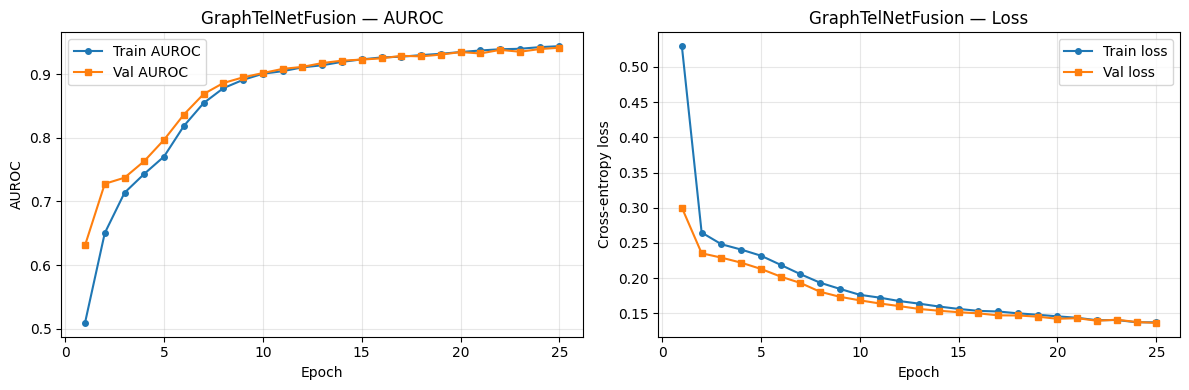

In [27]:
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_df["epoch"], hist_df["train_auc"], label="Train AUROC", marker="o", ms=4)
ax1.plot(hist_df["epoch"], hist_df["val_auc"],   label="Val AUROC",   marker="s", ms=4)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("AUROC")
ax1.set_title("GraphTelNetFusion — AUROC"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss", marker="o", ms=4)
ax2.plot(hist_df["epoch"], hist_df["val_loss"],   label="Val loss",   marker="s", ms=4)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Cross-entropy loss")
ax2.set_title("GraphTelNetFusion — Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate GraphTelNetFusion

In [28]:
# evaluate on test set
y_val, p_val = predict_loader(fusion_model, val_loader)
y_te,  p_te  = predict_loader(fusion_model, test_loader)

thr_fusion      = youden_threshold(y_val, p_val)
fusion_metrics  = eval_probs(y_te, p_te, thr=thr_fusion)

print("=== GraphTelNetFusion — Test Set Metrics ===")
for k, v in fusion_metrics.items():
    print(f"  {k}: {v}")

=== GraphTelNetFusion — Test Set Metrics ===
  AUROC: 0.9265
  AUPRC: 0.9916
  ACC: 0.8332
  SENSITIVITY: 0.8299
  SPECIFICITY: 0.8777
  PRECISION: 0.989
  F1: 0.9025
  THR: 0.9424
  TN_FP_FN_TP: [122, 17, 313, 1527]


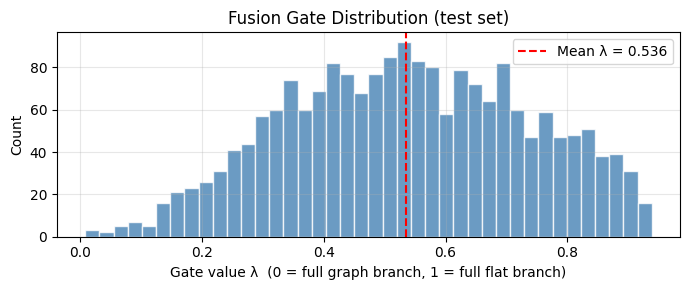

Mean λ = 0.5356 | Std = 0.1979


In [29]:
# --- Gate distribution ---
fusion_model.eval()
all_gates = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, lam = fusion_model(batch, return_gate=True)
        all_gates.append(lam.squeeze(-1).cpu().numpy())

gates = np.concatenate(all_gates)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(gates, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(gates.mean(), color="red", linestyle="--", label=f"Mean λ = {gates.mean():.3f}")
ax.set_xlabel("Gate value λ  (0 = full graph branch, 1 = full flat branch)")
ax.set_ylabel("Count")
ax.set_title("Fusion Gate Distribution (test set)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Mean λ = {gates.mean():.4f} | Std = {gates.std():.4f}")

## Paper Baseline — SUMMARY + Random Forest

Reproduces the spirit of *Shah & Sethuraman (2025)*: pooled telomere statistics as features, Random Forest classifier with the paper's optimal hyperparameters.  
The same patient-level train/val/test split is used for a fair comparison.

In [30]:
# --- SUMMARY feature matrix ---
feat_summary = pd.DataFrame(index=used_samples)
feat_summary["telomere_score"] = telomere_score                         # mean expression Z across core genes
feat_summary["expr_mean_z"]   = X_expr.mean(axis=1)                     # mean Z across all graph genes
feat_summary["expr_max_z"]    = X_expr.max(axis=1)                      # max Z across all graph genes
feat_summary["mut_total"]     = mut_count.sum(axis=1)                   # total mutations in telomere genes
feat_summary["nonsyn_total"]  = nonsyn_count.sum(axis=1)                # non-synonymous mutations
feat_summary["lof_genes"]     = lof_flag.sum(axis=1)                    # number of genes with LoF mutations

X_summary = feat_summary.values.astype(np.float32)
print(f"SUMMARY feature matrix: {X_summary.shape}")

scaler_rf = StandardScaler()
X_tr = scaler_rf.fit_transform(X_summary[train_idx])
X_va = scaler_rf.transform(X_summary[val_idx])
X_te = scaler_rf.transform(X_summary[test_idx])
y_tr, y_va, y_te_rf = Y[train_idx], Y[val_idx], Y[test_idx]

rf = RandomForestClassifier(
    n_estimators = RF_N_ESTIMATORS,
    max_depth    = RF_MAX_DEPTH,
    max_features = RF_MAX_FEATURES,
    bootstrap    = True,
    oob_score    = True,
    n_jobs       = -1,
    random_state = SEED,
)
rf.fit(X_tr, y_tr)
print(f"RF OOB accuracy: {rf.oob_score_:.4f}")

p_val_rf = rf.predict_proba(X_va)[:, 1]
p_te_rf  = rf.predict_proba(X_te)[:, 1]

thr_rf      = youden_threshold(y_va, p_val_rf)
rf_metrics  = eval_probs(y_te_rf, p_te_rf, thr=thr_rf)

print("\n=== SUMMARY-RF — Test Set Metrics ===")
for k, v in rf_metrics.items():
    print(f"  {k}: {v}")

SUMMARY feature matrix: (9913, 6)
RF OOB accuracy: 0.9247

=== SUMMARY-RF — Test Set Metrics ===
  AUROC: 0.7067
  AUPRC: 0.9675
  ACC: 0.5806
  SENSITIVITY: 0.5701
  SPECIFICITY: 0.7194
  PRECISION: 0.9642
  F1: 0.7165
  THR: 0.9318
  TN_FP_FN_TP: [100, 39, 791, 1049]


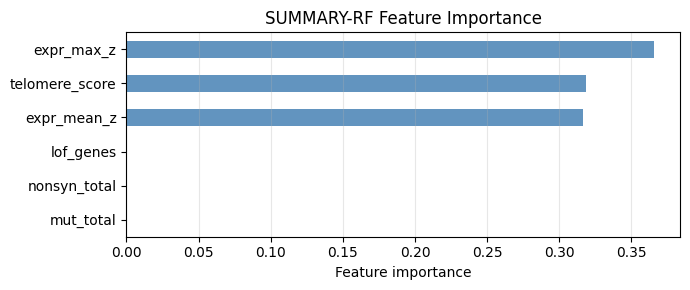

In [31]:
# --- RF feature importance ---
fi = pd.Series(rf.feature_importances_, index=feat_summary.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
fi.plot.barh(ax=ax, color="steelblue", alpha=0.85)
ax.set_xlabel("Feature importance")
ax.set_title("SUMMARY-RF Feature Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Final Comparison

In [32]:
COLS = ["AUROC", "AUPRC", "ACC", "SENSITIVITY", "SPECIFICITY", "PRECISION", "F1", "THR"]

comparison = pd.DataFrame([
    {"Model": "SUMMARY-RF  (paper approach)",
     **{k: rf_metrics[k] for k in COLS}},
    {"Model": f"GraphTelNetFusion  ({len(CORE_GENE_LIST)} genes)",
     **{k: fusion_metrics[k] for k in COLS}},
]).set_index("Model")

print("=" * 70)
print(comparison.to_string())
print("=" * 70)

styled = comparison.style.highlight_max(axis=0, props="background-color: black; font-weight: bold")
styled

                                AUROC   AUPRC     ACC  SENSITIVITY  SPECIFICITY  PRECISION      F1     THR
Model                                                                                                     
SUMMARY-RF  (paper approach)   0.7067  0.9675  0.5806       0.5701       0.7194     0.9642  0.7165  0.9318
GraphTelNetFusion  (15 genes)  0.9265  0.9916  0.8332       0.8299       0.8777     0.9890  0.9025  0.9424


,AUROC,AUPRC,ACC,SENSITIVITY,SPECIFICITY,PRECISION,F1,THR
Model,,,,,,,,
SUMMARY-RF (paper approach),0.706700,0.967500,0.580600,0.570100,0.719400,0.964200,0.716500,0.931800
GraphTelNetFusion (15 genes),0.926500,0.991600,0.833200,0.829900,0.877700,0.989000,0.902500,0.942400


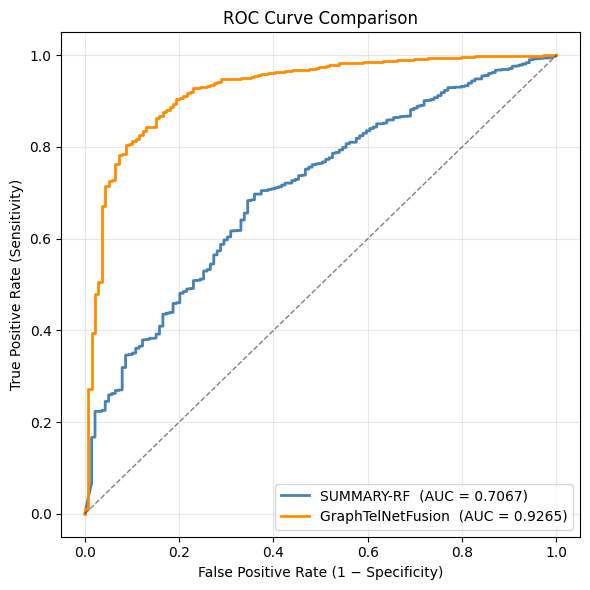

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))

for label, y_true, y_prob, color in [
    ("SUMMARY-RF",         y_te_rf, p_te_rf, "steelblue"),
    ("GraphTelNetFusion",  y_te,    p_te,    "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{label}  (AUC = {auc_val:.4f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curve Comparison")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

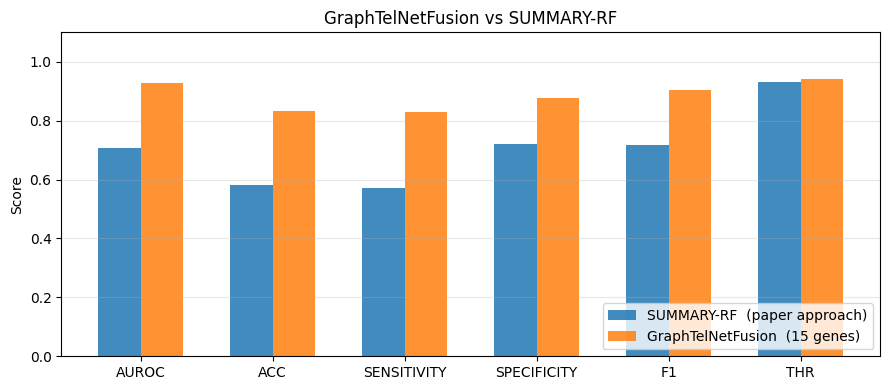

In [34]:
bar_cols = ["AUROC", "ACC", "SENSITIVITY", "SPECIFICITY", "F1", "THR"]
bar_df   = comparison[bar_cols]

x     = np.arange(len(bar_cols))
width = 0.32
fig, ax = plt.subplots(figsize=(9, 4))

for i, (idx_label, row) in enumerate(bar_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=idx_label, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(bar_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("GraphTelNetFusion vs SUMMARY-RF")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()